In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv(r"C:\Users\MRUGANK KAPSE\Downloads\train.csv\train.csv")
print(df)
print(df.describe())
print(df.info())
print(df.isnull().sum())

      Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
1          2  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
2          3  CA-2017-138688  12/06/2017  16/06/2017    Second Class   
3          4  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
4          5  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
...      ...             ...         ...         ...             ...   
9795    9796  CA-2017-125920  21/05/2017  28/05/2017  Standard Class   
9796    9797  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9797    9798  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9798    9799  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9799    9800  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520       Claire Gute   Consumer  United 

In [9]:
df['Postal Code']=df['Postal Code'].fillna(df['Postal Code'].min())
print(df.isnull().sum())
df['Postal Code']=df['Postal Code'].astype(int)
print(df['Postal Code'].dtype)

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64
int64


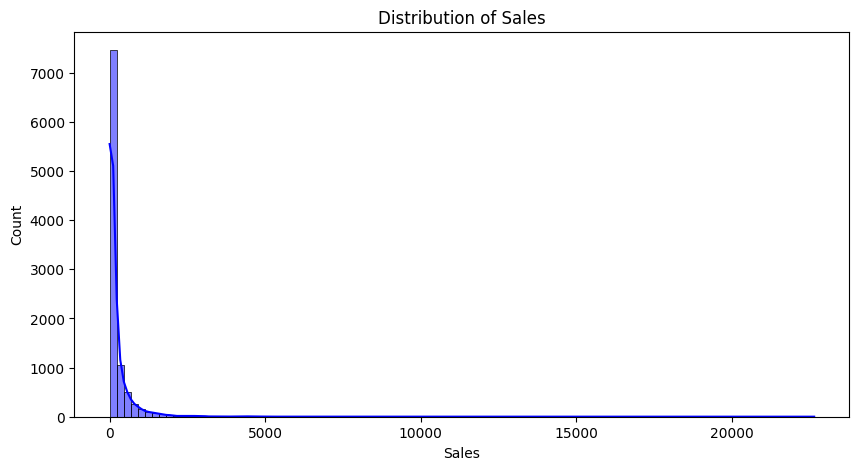

In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Sales'], bins=100, color='blue', kde=True)
plt.title('Distribution of Sales')
plt.show()

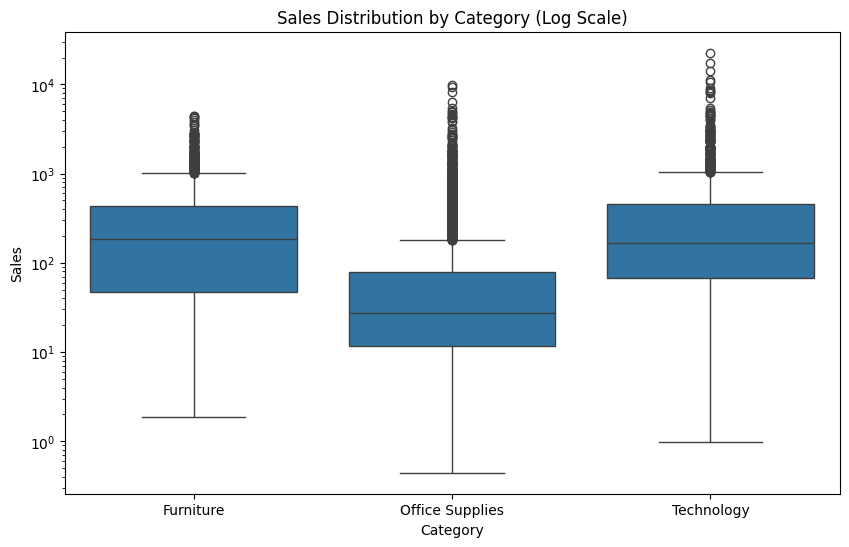

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Sales', data=df)
plt.yscale('log') 
plt.title('Sales Distribution by Category (Log Scale)')
plt.show()


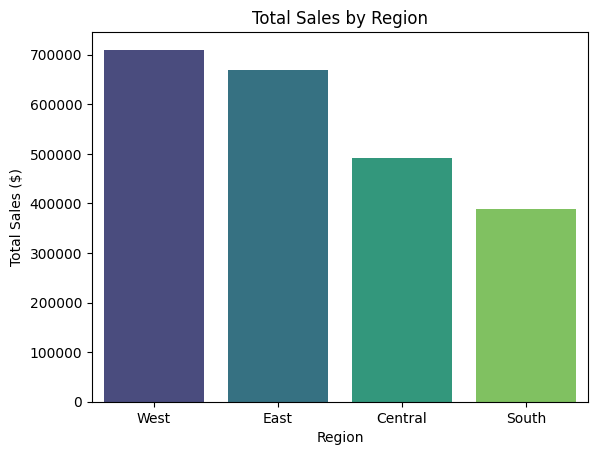

In [15]:
region_sales = df.groupby('Region')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)
sns.barplot(x='Region', y='Sales', data=region_sales, hue='Region', palette='viridis')
plt.title('Total Sales by Region')
plt.ylabel('Total Sales ($)')
plt.show()

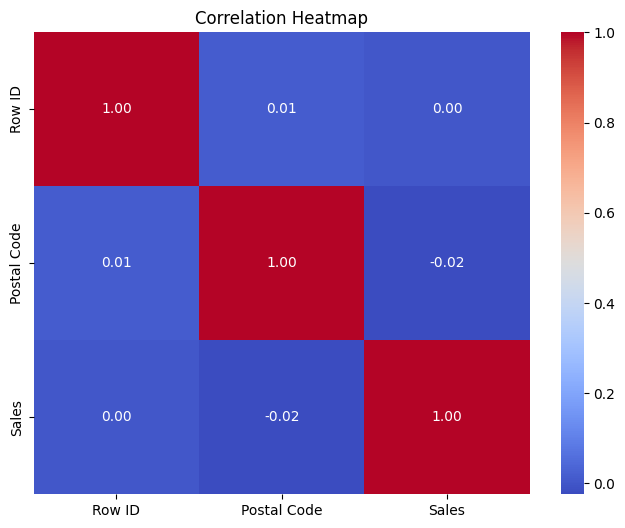

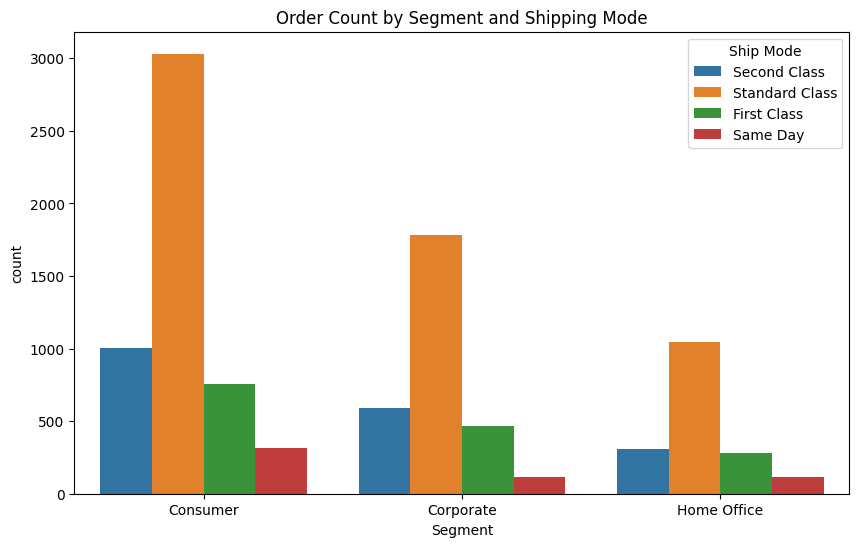

In [6]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Segment', hue='Ship Mode', data=df)
plt.title('Order Count by Segment and Shipping Mode')
plt.show()

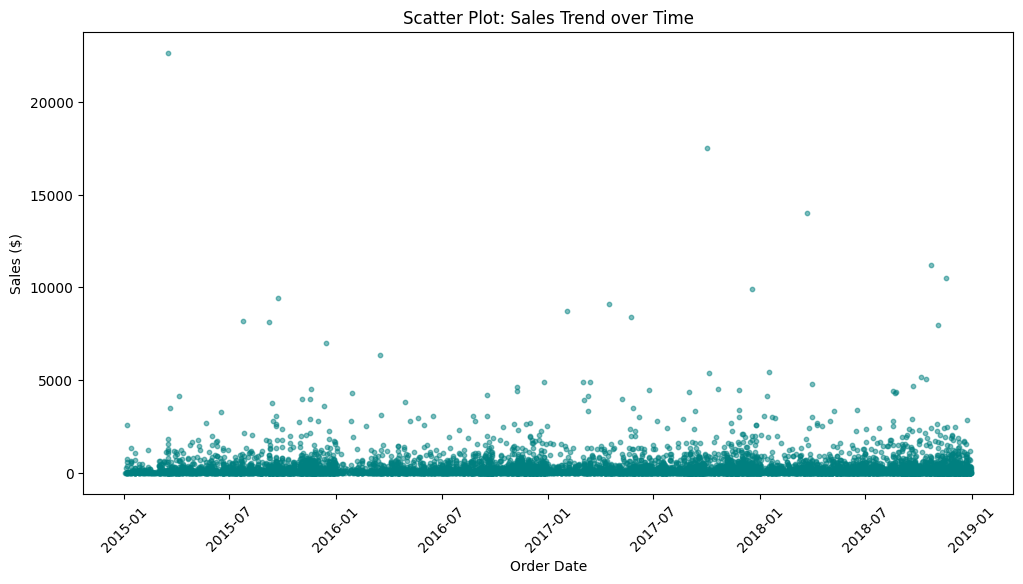

In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')

# --- 1. Standard Scatter Plot (Sales vs. Time) ---
plt.figure(figsize=(12, 6))
plt.scatter(df['Order Date'], df['Sales'], alpha=0.5, color='teal', s=10)
plt.title('Scatter Plot: Sales Trend over Time')
plt.xlabel('Order Date')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.savefig('scatter_sales_time.png')